In [15]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
!pip install wordcloud
import matplotlib.pyplot as plt
import nltk
from nltk import tokenize
import seaborn as sns
from string import punctuation
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk import ngrams
import numpy as np

In [28]:
from wordcloud import WordCloud

In [16]:
nltk.download("all")


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\pdelgado\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\abc.zip.
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\pdelgado\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\pdelgado\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\pdelgado\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\pdelgado\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]  

True

In [17]:
!pip install unidecode
import unidecode   

In [30]:
df = pd.read_csv('balanced_ai_human_prompts.csv')
print(df)

                                                   text  generated
0     Machine learning, a subset of artificial intel...          1
1     A decision tree, a prominent machine learning ...          1
2     Education, a cornerstone of societal progress,...          1
3     Computers, the backbone of modern technology, ...          1
4     Chess, a timeless game of strategy and intelle...          1
...                                                 ...        ...
2745  Generate a detailed summary of global healthca...          1
2746  Compose an in-depth exploration of financial t...          1
2747  Generate a detailed summary of autonomous vehi...          1
2748  Develop a persuasive argument about internet o...          1
2749  Generate a detailed summary of supply chain ma...          1

[2750 rows x 2 columns]


In [12]:
#balanceamento dos dados 
print("Distribuição das categorias:\n",df.generated.value_counts())

Distribuição das categorias:
 generated
1    1375
0    1375
Name: count, dtype: int64


In [22]:
#vetorizar e gerar uma bag of words
vetorizar = CountVectorizer(lowercase = False)
bag_of_words = vetorizar.fit_transform(df.text)


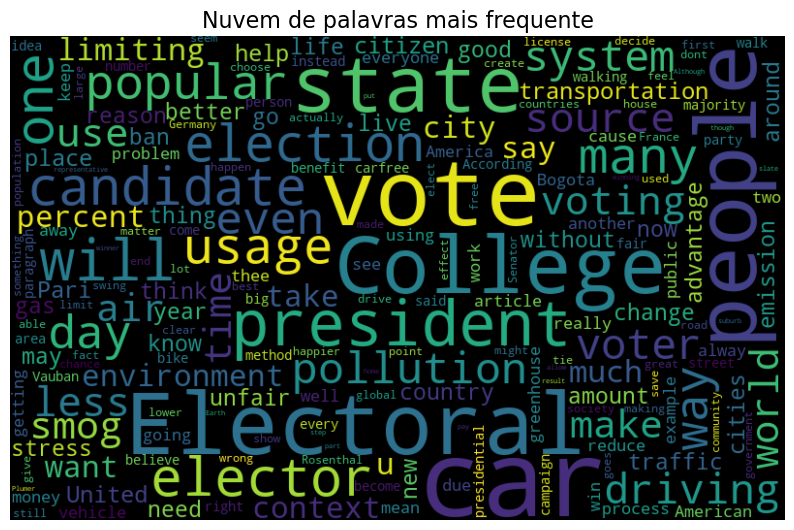

In [29]:
#Gerando WordCloud com as palavras mais frequentes do texto
todas_palavras =' '.join([texto for texto in df.text])
nuvem_de_palavras = WordCloud(width = 800, height = 500,
                              max_font_size = 110,
                              collocations = False).generate(todas_palavras)

plt.figure(figsize = (10,7))
plt.imshow(nuvem_de_palavras, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de palavras mais frequente', fontsize = 16)
plt.show()

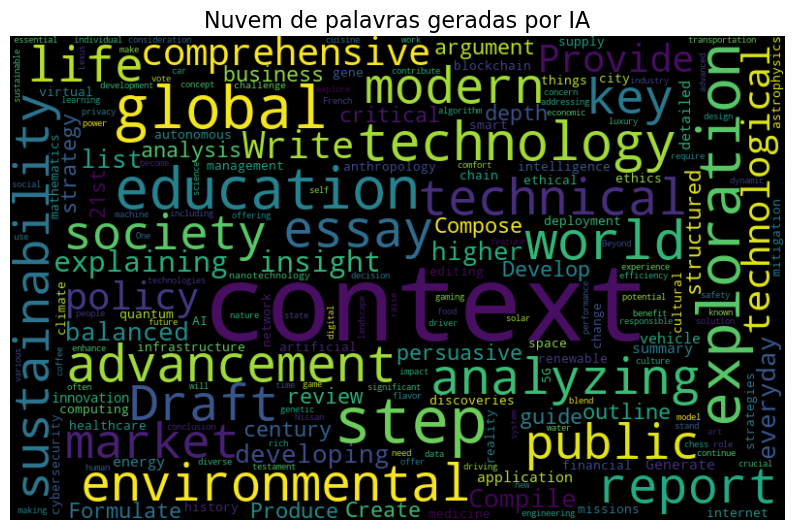

In [35]:
#Função para exibir uma WordCloud com os textos gerados por IA
def nuvem_palavras_ia(texto, coluna_texto):
    texto_positivo = texto.query("generated == 1")
    todas_palavras = ' '.join([texto for texto in texto_positivo[coluna_texto]])

    nuvem_palavras = WordCloud(width= 800, height= 500,
                              max_font_size = 110,
                              collocations = False).generate(todas_palavras)
    plt.figure(figsize=(10,7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis("off")
    plt.title('Nuvem de palavras geradas por IA', fontsize = 16)
    plt.show()

nuvem_palavras_ia(df,'text')


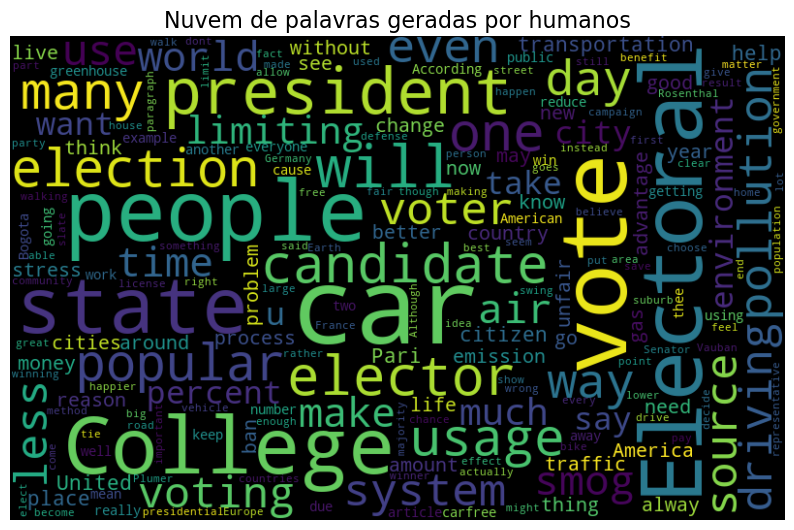

In [36]:
#Função para exibir uma WordCloud com os textos gerados por humanos
def nuvem_palavras_humano(texto, coluna_texto):
    texto_positivo = texto.query("generated == 0")
    todas_palavras = ' '.join([texto for texto in texto_positivo[coluna_texto]])

    nuvem_palavras = WordCloud(width= 800, height= 500,
                              max_font_size = 110,
                              collocations = False).generate(todas_palavras)
    plt.figure(figsize=(10,7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis("off")
    plt.title('Nuvem de palavras geradas por humanos', fontsize = 16)
    plt.show()

nuvem_palavras_humano(df,'text')

In [40]:
#Tokenizando o dataset
token_espaco = tokenize.WhitespaceTokenizer()
token_frase = token_espaco.tokenize(todas_palavras)
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'the': 45990, 'of': 24721, 'to': 23693, 'a': 19639, 'and': 17764, 'in': 15115, 'is': 12389, 'that': 10569, 'for': 8890, 'are': 7261, ...})

In [43]:
#Salvando as StopWords em uma variável
palavras_irrelevantes = nltk.corpus.stopwords.words('english')

In [47]:
#Separando o conjunto em treino e teste
treino, teste, classe_treino, classe_teste = train_test_split(bag_of_words, df.generated, random_state = 42)

In [48]:
#Função para medir a acurácia de cada tratamento realizado
def classificar_texto(texto, coluna_texto, coluna_classificacao):
    vetorizar = CountVectorizer(lowercase=False)
    bag_of_words = vetorizar.fit_transform(texto[coluna_texto])
    treino, teste, classe_treino, classe_teste = train_test_split(bag_of_words,
                                                              texto[coluna_classificacao],
                                                              random_state = 42)
    regressao_logistica = LogisticRegression()
    regressao_logistica.fit(treino, classe_treino)
    return regressao_logistica.score(teste, classe_teste)

In [50]:
#Modelo de Based Line
regressao_logistica = LogisticRegression()
regressao_logistica.fit(treino, classe_treino)
acuracia_based = regressao_logistica.score(teste, classe_teste)

In [52]:
#Tratamento 1 - Remoção de StopWords
frase_processada = list()
for opiniao in df.text:
    nova_frase = list()
    palavras_texto = token_espaco.tokenize(opiniao)
    for palavra in palavras_texto:
        if palavra not in palavras_irrelevantes:
            nova_frase.append(palavra)
    frase_processada.append(' '.join(nova_frase))

df["tratamento_1"] = frase_processada
acuracia_1 = classificar_texto(df, "tratamento_1", "generated")

In [53]:
#Tratamento 2 - Remoção de pontuação
token_pontuacao = tokenize.WordPunctTokenizer()
pontuacao = list()
for ponto in punctuation:
    pontuacao.append(ponto)

pontuacao_stopwords = pontuacao + palavras_irrelevantes #adicionando o tratamento 1 ao tratamento 2

frase_processada = list()
for opiniao in df["tratamento_1"]:
    nova_frase = list()
    palavras_texto = token_pontuacao.tokenize(opiniao)
    for palavra in palavras_texto:
        if palavra not in pontuacao_stopwords:
            nova_frase.append(palavra)
    frase_processada.append(' '.join(nova_frase))

df["tratamento_2"] = frase_processada
acuracia_2 = classificar_texto(df, "tratamento_2", "generated")

In [54]:
#Tratamento 3 - Removendo acentuação
sem_acentos = [unidecode.unidecode(texto) for texto in df["tratamento_2"]]
stop_words_sem_acento = [unidecode.unidecode(texto) for texto in pontuacao_stopwords]

df["tratamento_3"] = sem_acentos

frase_processada = list()
for opiniao in df["tratamento_3"]:
    nova_frase = list()
    palavras_texto = token_pontuacao.tokenize(opiniao)
    for palavra in palavras_texto:
        if palavra not in pontuacao_stopwords:
            nova_frase.append(palavra)
    frase_processada.append(' '.join(nova_frase))

df["tratamento_3"] = frase_processada
acuracia_3 = classificar_texto(df, "tratamento_3", "generated")

In [55]:
#Tratamento 4 - Convertendo todas as palavras para o minúsculo
frase_processada = list()
for opiniao in df["tratamento_3"]:
    nova_frase = list()
    opiniao = opiniao.lower()
    palavras_texto = token_pontuacao.tokenize(opiniao)
    for palavra in palavras_texto:
        if palavra not in stop_words_sem_acento:
            nova_frase.append(palavra)
    frase_processada.append(' '.join(nova_frase))

df["tratamento_4"] = frase_processada
acuracia_4 = classificar_texto(df, "tratamento_4", "generated")

In [56]:
#Tratamento 5 - Removendo prefixos e sufixos
stemmer = PorterStemmer()

frase_processada = list()
for opiniao in df["tratamento_4"]:
    nova_frase = list()
    palavras_texto = token_pontuacao.tokenize(opiniao)
    for palavra in palavras_texto:
        if palavra not in stop_words_sem_acento:
            nova_frase.append(stemmer.stem(palavra))
    frase_processada.append(' '.join(nova_frase))

df["tratamento_5"] = frase_processada
acuracia_5 = classificar_texto(df, "tratamento_5", "generated")

In [57]:
#Tratamento 6 - TF-IDF

#Aplicando aos dados brutos
tfidf = TfidfVectorizer(lowercase=False)
tfidf_bruto = tfidf.fit_transform(df["text"])
treino, teste, classe_treino, classe_teste = train_test_split(tfidf_bruto, df["generated"], random_state = 42)
regressao_logistica.fit(treino, classe_treino)
acuracia_tfidf_bruto = regressao_logistica.score(teste, classe_teste)

#Aplicando ao tratamento 5
tfidf_tratados = tfidf.fit_transform(df["tratamento_5"])
treino, teste, classe_treino, classe_teste = train_test_split(tfidf_tratados, df["generated"], random_state = 42)
regressao_logistica.fit(treino, classe_treino)
acuracia_tfidf_tratados = regressao_logistica.score(teste, classe_teste)

#Tratamento 7 - Ngrams
tfidf = TfidfVectorizer(lowercase=False, ngram_range = (1,2))
vetor_tfidf = tfidf.fit_transform(df["tratamento_5"])
treino, teste, classe_treino, classe_teste = train_test_split(vetor_tfidf, df["generated"], random_state = 42)
regressao_logistica.fit(treino, classe_treino)
acuracia_tfidf_ngrams = regressao_logistica.score(teste, classe_teste)

In [58]:
#Acurácia de cada modelo
print('Acurácia do tratamento 1:', acuracia_1)
print('Acurácia do tratamento 2:', acuracia_2)
print('Acurácia do tratamento 3:', acuracia_3)
print('Acurácia do tratamento 4:', acuracia_4)
print('Acurácia do tratamento 5:', acuracia_5)
print('Acurácia aplicando TF-IDF nos dados brutos:', acuracia_tfidf_bruto)
print('Acurácia aplicando TF-IDF nos dados tratados:', acuracia_tfidf_tratados)
print('Acurácia aplicando com n-grams:', acuracia_tfidf_ngrams)

Acurácia do tratamento 1: 0.997093023255814
Acurácia do tratamento 2: 0.997093023255814
Acurácia do tratamento 3: 0.997093023255814
Acurácia do tratamento 4: 0.9956395348837209
Acurácia do tratamento 5: 0.9956395348837209
Acurácia aplicando TF-IDF nos dados brutos: 0.9869186046511628
Acurácia aplicando TF-IDF nos dados tratados: 0.9883720930232558
Acurácia aplicando com n-grams: 0.9898255813953488
